# Bagging Learning Tool — Manual Walkthrough on Iris
This notebook **manually implements** the four sampling strategies used in ensemble methods, step-by-step.
No sklearn BaggingClassifier here — you build each tree yourself so you understand what's happening inside.

| Strategy | Rows | Features |
|----------|------|----------|
| **Bagging** | With replacement | All |
| **Pasting** | Without replacement | All |
| **Random Subspaces** | All rows | Random subset |
| **Random Patches** | With replacement | Random subset |


## Step 1: Load and Explore Dataset
Using the Iris dataset — keeping only `Versicolor` (1) and `Virginica` (2) for binary classification.

In [3]:
import pandas as pd
df = pd.read_csv(r'd:\PENDRIVE 32 GB\Game\AI_PROJECTS\Machine Learning\100-days-of-machine-learning-main\day59-classification-metrics\Iris.csv')

In [4]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,setosa
1,2,4.9,3.0,1.4,0.2,setosa
2,3,4.7,3.2,1.3,0.2,setosa
3,4,4.6,3.1,1.5,0.2,setosa
4,5,5.0,3.6,1.4,0.2,setosa


In [5]:
df = df.iloc[:,1:]

In [6]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## Step 2: Encode Species Labels
`LabelEncoder` converts string species names → integers (0, 1, 2).

In [7]:
from sklearn.preprocessing import LabelEncoder

In [8]:
encoder = LabelEncoder()

In [9]:
df['Species'] = encoder.fit_transform(df['Species'])

In [10]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## Step 3: Filter to 2 Classes and Select Features
Keep only Versicolor (1) and Virginica (2). Use `SepalWidthCm` and `PetalLengthCm` as the 2 features for easy visualisation.

In [11]:
df = df[df['Species'] != 0][['SepalWidthCm','PetalLengthCm','Species']]

In [12]:
df.head()

,SepalWidthCm,PetalLengthCm,Species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


## Step 4: Visualise the 2-Class Dataset
Scatter plot — the two classes should be roughly separable.

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

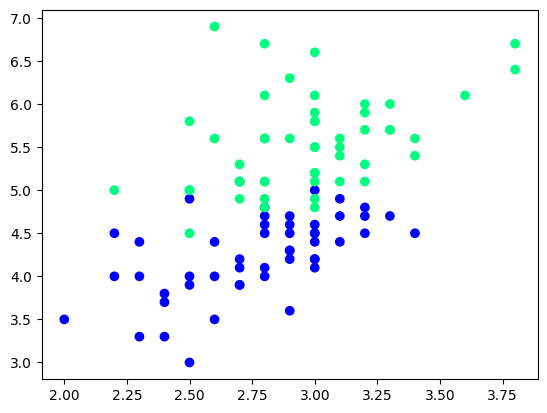

In [14]:
plt.scatter(df['SepalWidthCm'],df['PetalLengthCm'],c=df['Species'],cmap='winter')

## Step 5: Create Train / Val / Test Splits
- `df_train` — 10 rows for training each tree (small on purpose to show diversity)
- `df_val` — 5 rows for validation (used as X_test inside `evaluate`)
- `df_test` — 5 rows for final testing


In [15]:
df_train = df.iloc[:60,:].sample(10)
df_train

,SepalWidthCm,PetalLengthCm,Species
95,3.0,4.2,1
89,2.5,4.0,1
57,2.4,3.3,1
67,2.7,4.1,1
84,3.0,4.5,1
69,2.5,3.9,1
101,2.7,5.1,2
96,2.9,4.2,1
109,3.6,6.1,2
87,2.3,4.4,1


In [16]:
# Taking only 10 rows for training
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [17]:
df_train

,SepalWidthCm,PetalLengthCm,Species
138,3.0,4.8,2
106,2.5,4.5,2
90,2.6,4.4,1
137,3.1,5.5,2
94,2.7,4.2,1
96,2.9,4.2,1
145,3.0,5.2,2
147,3.0,5.2,2
114,2.8,5.1,2
134,2.6,5.6,2


In [18]:
df_val

,SepalWidthCm,PetalLengthCm,Species
62,2.2,4.0,1
71,2.8,4.0,1
139,3.1,5.4,2
142,2.7,5.1,2
102,3.0,5.9,2


In [19]:
df_test

,SepalWidthCm,PetalLengthCm,Species
144,3.3,5.7,2
86,3.1,4.7,1
115,3.2,5.3,2
135,3.0,6.1,2
72,2.5,4.9,1


In [20]:
X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values

In [21]:
y_test

array([1, 1, 2, 2, 2])

---
## Case 1 — Bagging
### What Bagging Does
Each tree trains on a **bootstrap sample** — rows sampled **with replacement** (`replace=True`).
Because of replacement, some rows appear multiple times, others not at all.
Each of the 3 trees sees a different version of the 10 training rows → each tree is different.


# Case 1 - Bagging

In [23]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [22]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,SepalWidthCm,PetalLengthCm,Species
94,2.7,4.2,1
145,3.0,5.2,2
138,3.0,4.8,2
147,3.0,5.2,2
94,2.7,4.2,1
90,2.6,4.4,1
137,3.1,5.5,2
145,3.0,5.2,2


### Tree 1 — Bagging

In [24]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test,y_pred))
    

In [25]:
dt_bag1 = DecisionTreeClassifier()

### Tree 2 — Bagging
New bootstrap sample → different rows → different tree.

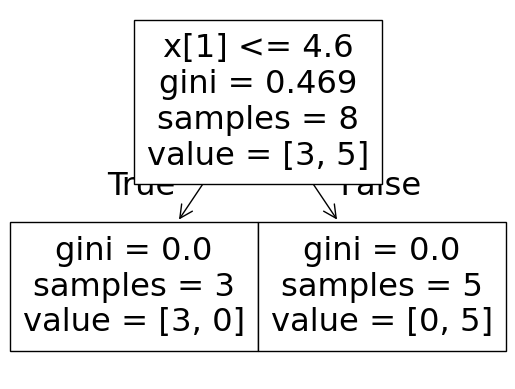

d:\PENDRIVE 32 GB\Game\AI_PROJECTS\Machine Learning\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
d:\PENDRIVE 32 GB\Game\AI_PROJECTS\Machine Learning\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0


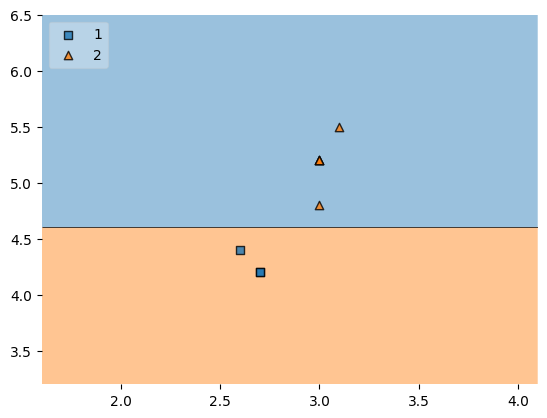

In [26]:
evaluate(dt_bag1,X,y)

In [27]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,SepalWidthCm,PetalLengthCm,Species
137,3.1,5.5,2
145,3.0,5.2,2
147,3.0,5.2,2
147,3.0,5.2,2
138,3.0,4.8,2
114,2.8,5.1,2
147,3.0,5.2,2
134,2.6,5.6,2


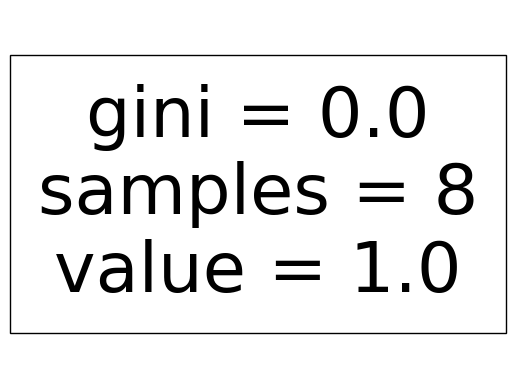

d:\PENDRIVE 32 GB\Game\AI_PROJECTS\Machine Learning\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
d:\PENDRIVE 32 GB\Game\AI_PROJECTS\Machine Learning\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.6


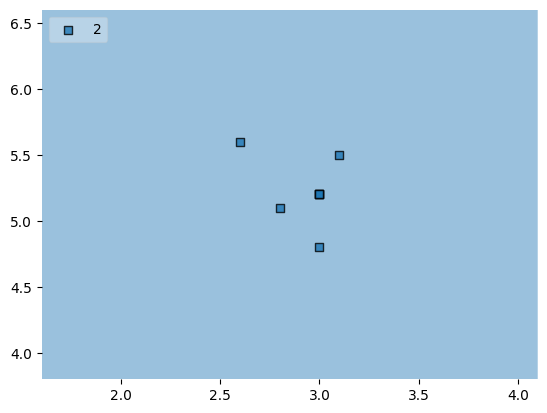

In [28]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2,X,y)

### Tree 3 — Bagging
Another bootstrap sample → another different tree.

In [29]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,SepalWidthCm,PetalLengthCm,Species
145,3.0,5.2,2
134,2.6,5.6,2
94,2.7,4.2,1
90,2.6,4.4,1
137,3.1,5.5,2
145,3.0,5.2,2
96,2.9,4.2,1
145,3.0,5.2,2


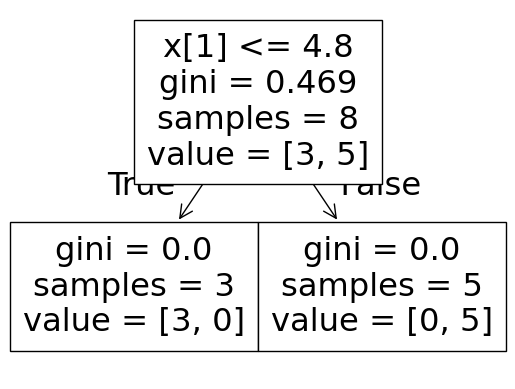

d:\PENDRIVE 32 GB\Game\AI_PROJECTS\Machine Learning\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
d:\PENDRIVE 32 GB\Game\AI_PROJECTS\Machine Learning\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0


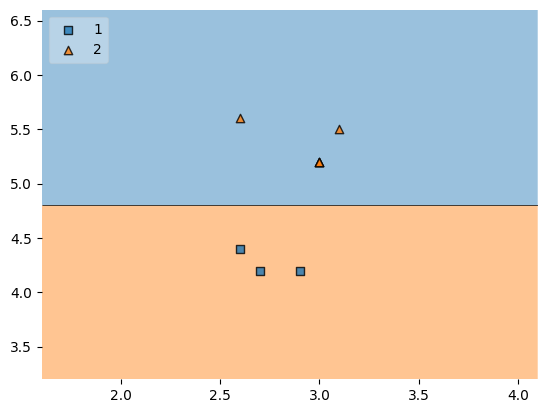

In [30]:
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3,X,y)

### Predict with All 3 Trees
Each tree may give a different prediction for the same input.
Final ensemble prediction = **majority vote** (2 out of 3).


## Predict

In [31]:
df_test

,SepalWidthCm,PetalLengthCm,Species
144,3.3,5.7,2
86,3.1,4.7,1
115,3.2,5.3,2
135,3.0,6.1,2
72,2.5,4.9,1


In [32]:
print("Predictor 1",dt_bag1.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 2",dt_bag2.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 3",dt_bag3.predict(np.array([2.2,5.0]).reshape(1,2)))

Predictor 1 [2]
Predictor 2 [2]
Predictor 3 [2]


d:\PENDRIVE 32 GB\Game\AI_PROJECTS\Machine Learning\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
d:\PENDRIVE 32 GB\Game\AI_PROJECTS\Machine Learning\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
d:\PENDRIVE 32 GB\Game\AI_PROJECTS\Machine Learning\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


---
## Case 2 — Pasting
### What Pasting Does
Same as Bagging but rows are sampled **without replacement** (`replace=False`).
No row appears twice in the same tree's training set.
Trees are less diverse than Bagging → usually slightly worse performance.


# Pasting

In [33]:
# Row sampling without replacement
df_train

,SepalWidthCm,PetalLengthCm,Species
138,3.0,4.8,2
106,2.5,4.5,2
90,2.6,4.4,1
137,3.1,5.5,2
94,2.7,4.2,1
96,2.9,4.2,1
145,3.0,5.2,2
147,3.0,5.2,2
114,2.8,5.1,2
134,2.6,5.6,2


---
## Case 3 — Random Subspaces
### What Random Subspaces Does
Each tree trains on **all rows** but only a **random subset of features** (columns).
`df1.sample(2, replace=True, axis=1)` samples 2 columns randomly.
Forces trees to be diverse by limiting which features they can use.


In [34]:
df_train.sample(8)

,SepalWidthCm,PetalLengthCm,Species
145,3.0,5.2,2
138,3.0,4.8,2
90,2.6,4.4,1
137,3.1,5.5,2
147,3.0,5.2,2
114,2.8,5.1,2
106,2.5,4.5,2
134,2.6,5.6,2


# Random Subspaces

In [35]:
df1 = pd.read_csv(r'd:\PENDRIVE 32 GB\Game\AI_PROJECTS\Machine Learning\100-days-of-machine-learning-main\day59-classification-metrics\Iris.csv')
df1 = df1.sample(10)

---
## Case 4 — Random Patches
### What Random Patches Does
The most aggressive sampling — **both** rows **and** features are randomly sampled.
Each tree sees a small, unique patch of the data.
This is how Random Forest works internally.


In [36]:
df1

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
31,32,5.4,3.4,1.5,0.4,setosa
90,91,5.5,2.6,4.4,1.2,versicolor
60,61,5.0,2.0,3.5,1.0,versicolor
30,31,4.8,3.1,1.6,0.2,setosa
55,56,5.7,2.8,4.5,1.3,versicolor
110,111,6.5,3.2,5.1,2.0,virginica
61,62,5.9,3.0,4.2,1.5,versicolor
16,17,5.4,3.9,1.3,0.4,setosa
123,124,6.3,2.7,4.9,1.8,virginica
93,94,5.0,2.3,3.3,1.0,versicolor


In [37]:
df1.sample(2,replace=True,axis=1)

,PetalLengthCm,SepalWidthCm
31,1.5,3.4
90,4.4,2.6
60,3.5,2.0
30,1.6,3.1
55,4.5,2.8
110,5.1,3.2
61,4.2,3.0
16,1.3,3.9
123,4.9,2.7
93,3.3,2.3
